# Week 2 - Day 4: EDA Part 1 - Distributions & Outliers

## Objective

Learn how to explore a dataset using Seaborn, identify distributions, and detect outliers using the IQR method.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../../Week 1/tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [10]:
numeric_columns = df.select_dtypes(include=["number"]).columns

print(numeric_columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


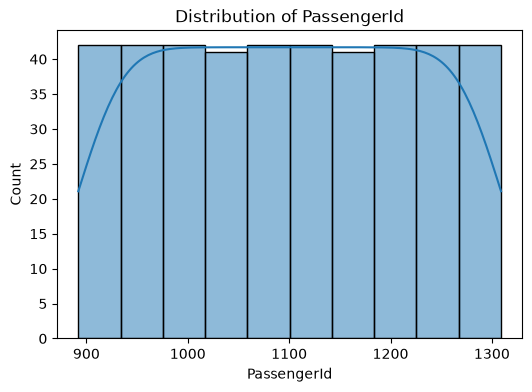

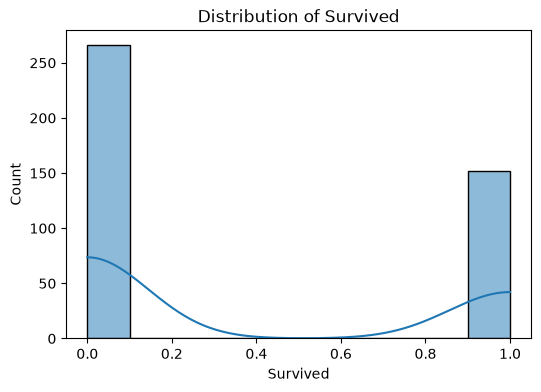

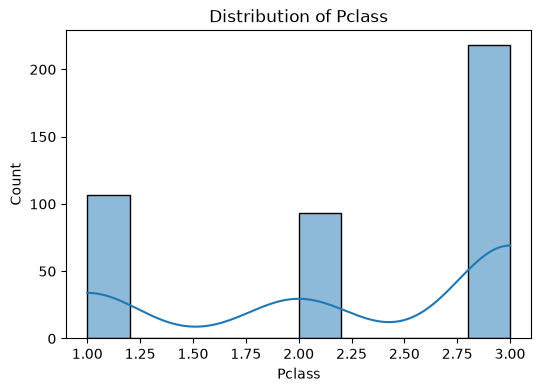

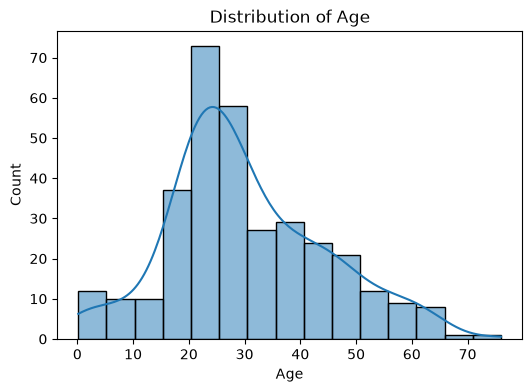

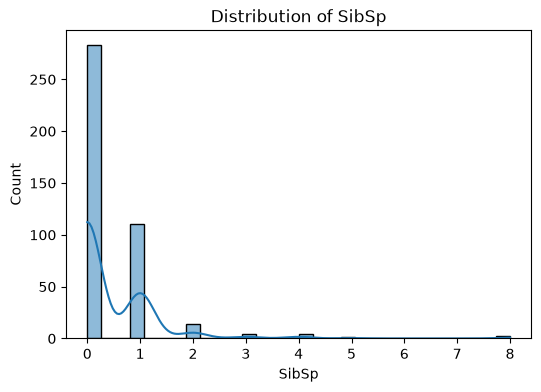

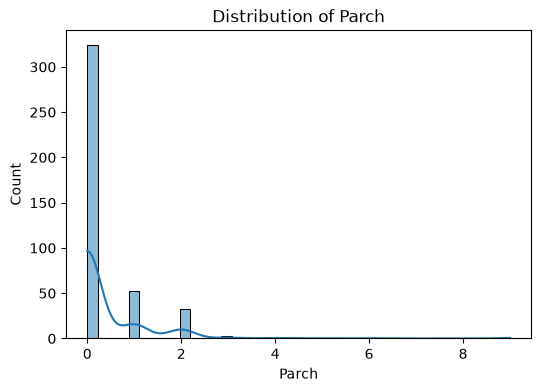

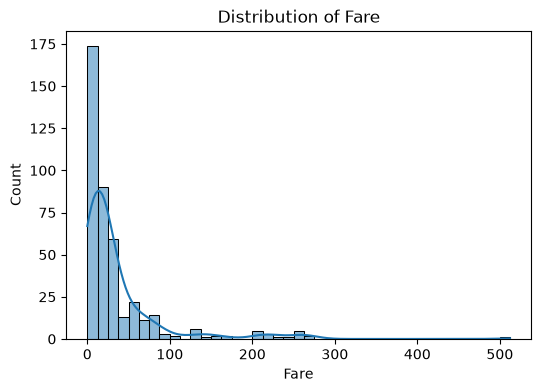

In [11]:
for column in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column].dropna(), kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

## Histogram Analysis

Histograms show how the values of each numeric variable are distributed.

The KDE curve helps visualize the overall shape of the distribution, making it easier to identify skewness or multiple peaks.

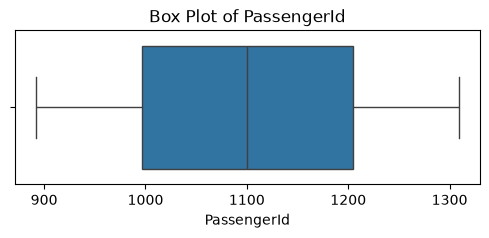

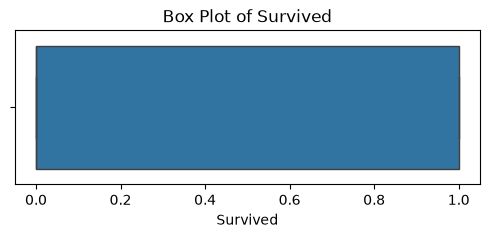

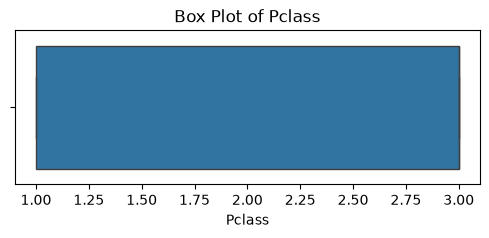

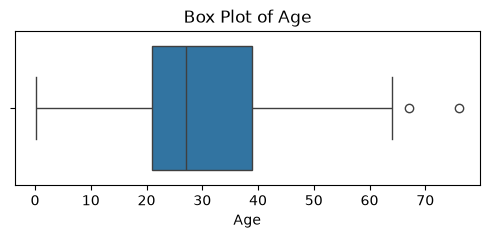

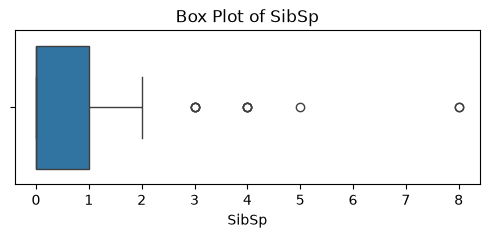

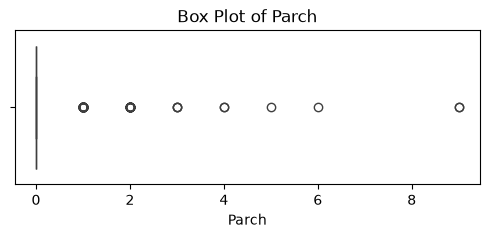

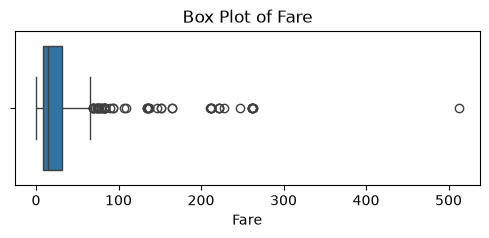

In [12]:
for column in numeric_columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

## Box Plot Analysis

Box plots display the median, quartiles, and potential outliers.

Points outside the whiskers may represent unusual observations that require further investigation.

In [13]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Age"] < lower_bound) | (df["Age"] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Q1: 21.0
Q3: 39.0
IQR: 18.0
Lower Bound: -6.0
Upper Bound: 66.0
Number of Outliers: 2


In [14]:
outliers[["PassengerId", "Age"]]

,PassengerId,Age
81,973,67.0
96,988,76.0


## Outlier Detection using the IQR Method

The IQR method was used to detect outliers in the **Age** column.

Values below the lower bound or above the upper bound are considered potential outliers.

These values should be investigated before deciding whether to keep, remove, or transform them.

In [18]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

print(categorical_columns)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


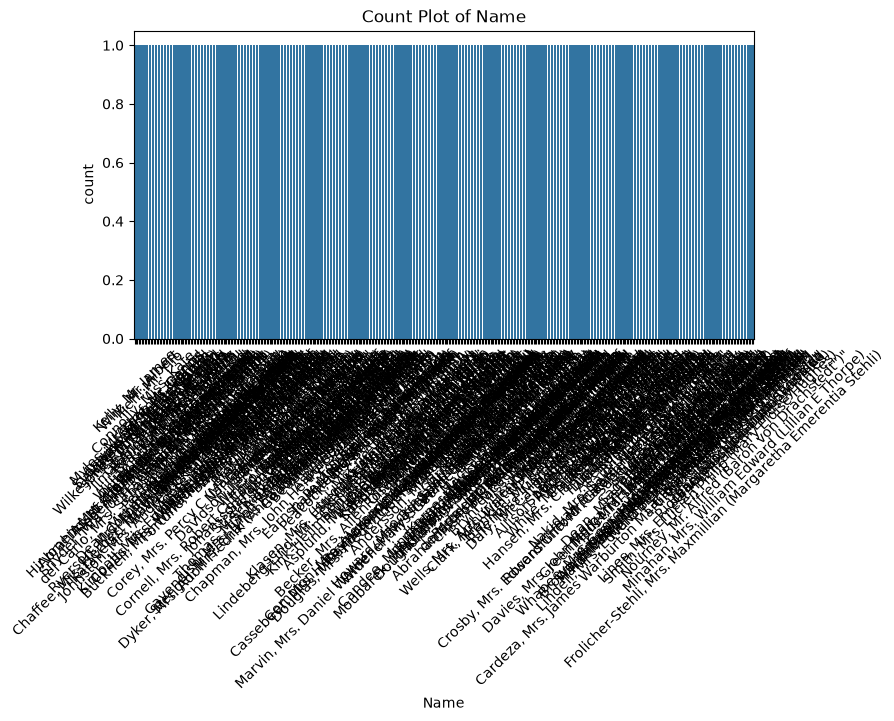

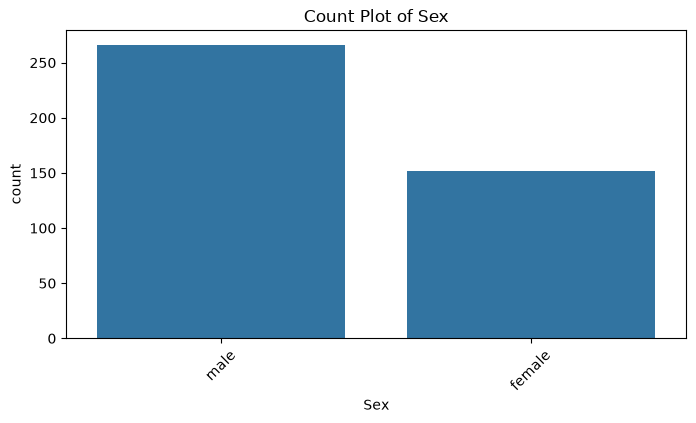

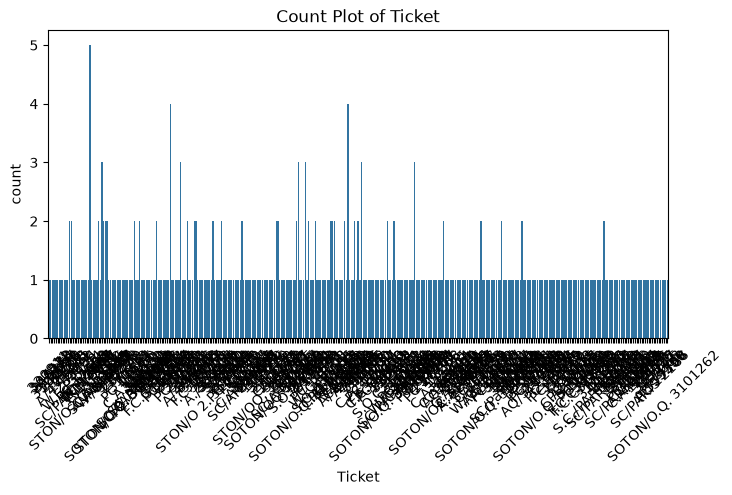

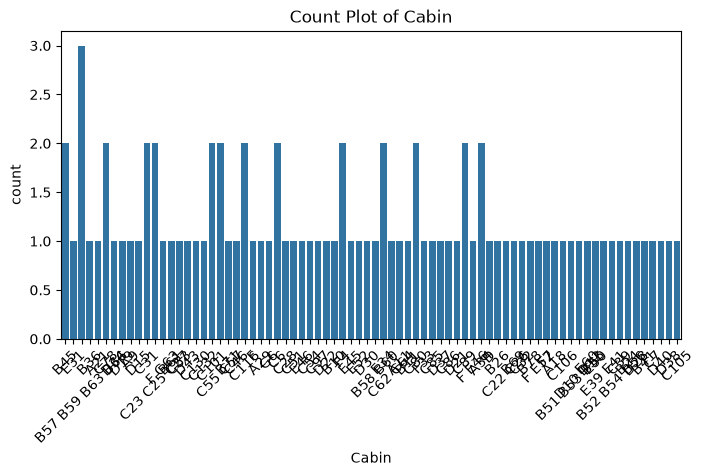

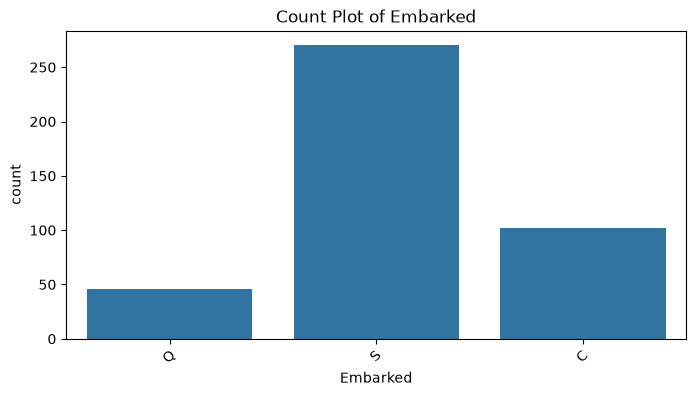

In [21]:
for column in categorical_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=column)
    plt.title(f"Count Plot of {column}")
    plt.xticks(rotation=45)
    plt.show()

## Count Plot Analysis

Count plots display the frequency of each category.

They help identify class imbalance and show whether some categories appear much more frequently than others.

In [22]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Name
Name
Kelly, Mr. James                                1
Wilkes, Mrs. James (Ellen Needs)                1
Myles, Mr. Thomas Francis                       1
Wirz, Mr. Albert                                1
Hirvonen, Mrs. Alexander (Helga E Lindqvist)    1
                                               ..
Spector, Mr. Woolf                              1
Oliva y Ocana, Dona. Fermina                    1
Saether, Mr. Simon Sivertsen                    1
Ware, Mr. Frederick                             1
Peter, Master. Michael J                        1
Name: count, Length: 418, dtype: int64

Sex
Sex
male      266
female    152
Name: count, dtype: int64

Ticket
Ticket
PC 17608              5
113503                4
CA. 2343              4
C.A. 31029            3
PC 17483              3
                     ..
A.5. 3236             1
PC 17758              1
SOTON/O.Q. 3101262    1
359309                1
2668                  1
Name: count, Length: 363, dtype: int64

Cabin
Cabin
B57 B5

# Summary

In this notebook, we performed Exploratory Data Analysis (EDA) on the Titanic dataset.

## Completed Tasks

- Loaded and explored the dataset.
- Examined numeric variables using histograms.
- Identified outliers visually with box plots.
- Detected outliers using the IQR method.
- Explored categorical variables using count plots.
- Interpreted the distributions and summarized the findings.

EDA helps us understand the data before applying machine learning models, making it easier to detect problems and choose appropriate preprocessing techniques.

## Count Plot Analysis

### Sex
The dataset contains more male passengers than female passengers.

### Embarked
Some embarkation ports have more passengers than others, indicating an uneven distribution.

### Pclass
Passenger classes are not equally represented. Some classes contain more passengers than others.

### Survived
The classes are imbalanced, meaning one outcome appears more frequently than the other.

# Final Conclusion

Exploratory Data Analysis (EDA) provides a clear understanding of the dataset before building machine learning models.

From this analysis, we:
- Explored the distributions of numerical variables.
- Visualized data using histograms and box plots.
- Detected potential outliers using the IQR method.
- Examined categorical variables using count plots.
- Identified possible class imbalance.

These insights help determine the appropriate preprocessing steps before model training.